In [2]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv("powerplant_data.csv")

In [6]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [8]:
X = df.drop("PE",axis =1)
y = df["PE"]

In [11]:
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [16]:
# split our data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled =  scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
X_test_scaled

array([[ 1.34499288,  0.23869298, -1.28658067, -1.10532538],
       [ 0.81095912,  1.36269098, -0.74140656,  0.26485915],
       [-0.2437241 , -0.73900436,  1.99970178, -0.19713193],
       ...,
       [-0.67068342, -1.15902881, -0.29951077, -0.10651852],
       [ 1.31420898,  1.33752097, -0.87346737, -0.44288647],
       [-0.2611237 , -0.27021304,  0.37433797,  1.10646548]],
      shape=(1914, 4))

In [27]:
!pip install torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 MB 1.5 MB/s  0:00:51 eta 0:00:010:00:02


In [28]:
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

In [23]:
type(X_train_scaled)

numpy.ndarray

In [31]:
type(y_train)
y_train.shape

(7654,)

In [33]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [35]:
train_loader = DataLoader(train_dataset, batch_size=32,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=32)

# Deep Learning

In [41]:
# Building our ANN Model

class ANN(nn.Module):

    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            # 1st hidden layer
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),

            # 2nd hidden layer
            nn.Linear(6, 6),
            nn.ReLU(),

            # output layer
            nn.Linear(6, 1)
        )

    def forward(self, x):
        return self.model(x)

In [43]:
import torch.optim as optim

model = ANN()

#loss, optimiser

crietrion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [49]:
# Train the ANN

train_losses=[]
val_losses = []
epochs =100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # total training loss for 1 epoch

    for xb,yb in train_loader:

        optimizer.zero_grad()
        outputs = model(xb) #forward prop.. predict output for the batch
        loss = crietrion(outputs,yb) #compute loss
        loss.backward( ) #back prop.. compute gradients
        optimizer.step() #params update

        running_loss +=loss.item() #loss is a  tensor => py float

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    #validation
    running_val_loss = 0.0

    with torch.no_grad(): #no gradient compute
        for xb,yb in test_loader:
            outputs = model(xb)
            loss = crietrion(outputs,yb)
            running_val_loss+= loss

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch ${epoch+1}/{epochs} ===> train loss =${epoch_train_loss} & val loss = ${epoch_val_loss}")
    
        

epoch $1/100 ===> train loss =$21.483669225374857 & val loss = $20.475078582763672
epoch $2/100 ===> train loss =$21.446623718738557 & val loss = $20.048423767089844
epoch $3/100 ===> train loss =$21.319634475310643 & val loss = $20.01108741760254
epoch $4/100 ===> train loss =$21.309708162148794 & val loss = $20.335834503173828
epoch $5/100 ===> train loss =$21.43645821213722 & val loss = $19.827838897705078
epoch $6/100 ===> train loss =$21.519399841626484 & val loss = $19.726959228515625
epoch $7/100 ===> train loss =$21.578421938419343 & val loss = $21.1555118560791
epoch $8/100 ===> train loss =$21.497202110290527 & val loss = $20.14737892150879
epoch $9/100 ===> train loss =$21.696019033590954 & val loss = $19.98312759399414
epoch $10/100 ===> train loss =$21.55680730740229 & val loss = $20.635374069213867
epoch $11/100 ===> train loss =$21.438653564453126 & val loss = $19.76064682006836
epoch $12/100 ===> train loss =$21.56744111776352 & val loss = $19.859519958496094
epoch $13/

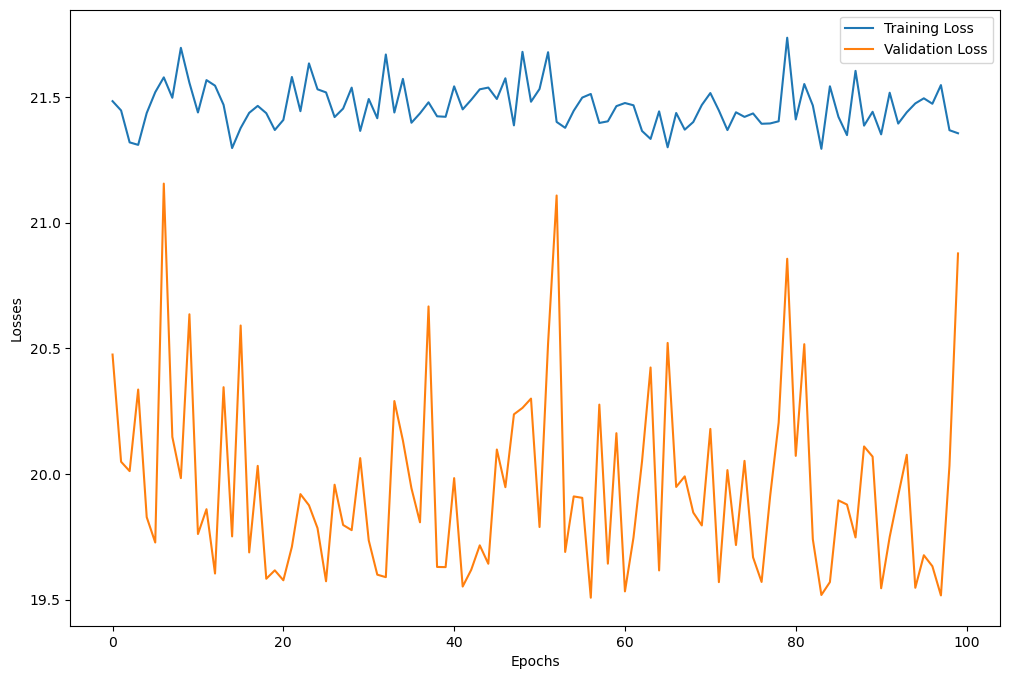

In [57]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.figure(figsize=(12,8))
plt.plot(loss_df["Training Loss"], label="Training Loss")
plt.plot(loss_df["Validation Loss"], label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()
plt.show()